## audio experiments

In [7]:
import os
import sys
import numpy as np
from gen_graph import gen_plots

# custom imports
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, ".."))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
from fir_host import train_fir
from data_proc.parse_audio_data import parse_audio, save_audio

import pickle
import matplotlib.pyplot as plt

N = 30000
with open("../data/train_set.pickle", "rb") as f:
    train_set = pickle.load(f)

with open("../data/test_set.pickle", "rb") as f:
    test_set = pickle.load(f)

train_x = [i[0] for i in train_set]
train_y = [i[1] for i in train_set]

weights, loss_hist = train_fir(train_x, train_y, N, 38, epochs=100)


Reverse differentiation of function rev_fir_loss:
def rev_fir_loss(noisy : In[Array[float]], _dnoisy_qqy7x3 : Out[Array[float]], clean : In[Array[float]], _dclean_V3SRrE : Out[Array[float]], weights : In[Array[float]], _dweights_tfJVtz : Out[Array[float]], N : In[int], _dN_ubDhQS : Out[int], K : In[int], _dK_bmqztr : Out[int], _dreturn_UyqRCo : In[float]) -> void:
	_t_int_0ihZGN : Array[int, 2040001]
	_stack_ptr_int_0ihZGN : int = (int)(0)
	_t_float_RJfqXb : Array[float, 2091000]
	_stack_ptr_float_RJfqXb : int = (int)(0)
	_loop_var_0_r2HEDm : int
	_loop_var_1_2hhhN2 : int
	_loop_var_1_2hhhN2_stack : Array[int, 51000]
	_loop_var_1_2hhhN2_stack_ptr : int
	_call_t_0_MDzWjm : int
	loss : float = (float)(0.0)
	_dloss_JUGkUB : float
	i : int = (K) - ((int)(1))
	sum : float = (float)(0.0)
	_dsum_72hdch : float
	j : int = (int)(0)
	(_t_int_0ihZGN)[_stack_ptr_int_0ihZGN] = _call_t_0_MDzWjm
	_stack_ptr_int_0ihZGN = (_stack_ptr_int_0ihZGN) + ((int)(1))
	_call_t_0_MDzWjm = (int)(0)
	diff : float 

training...:   1%|          | 1/100 [00:01<03:05,  1.88s/it]

Epoch 0 | Loss: 377.9585


training...: 100%|██████████| 100/100 [03:00<00:00,  1.80s/it]


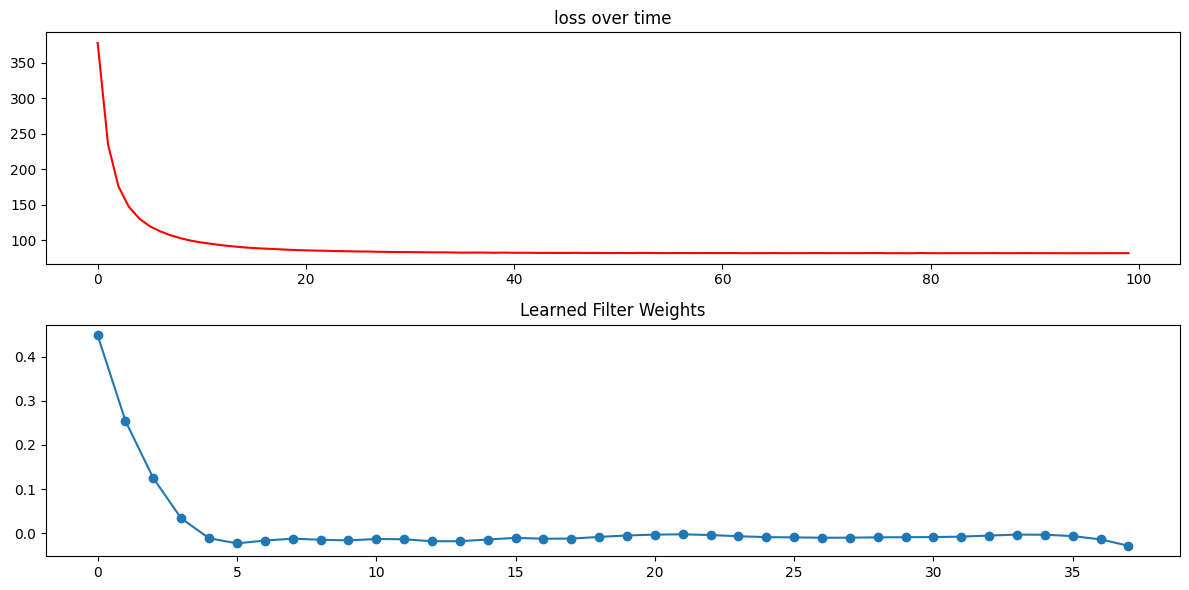

In [8]:
gen_plots(weights, loss_hist)

saved audio to: ../data/generated.wav


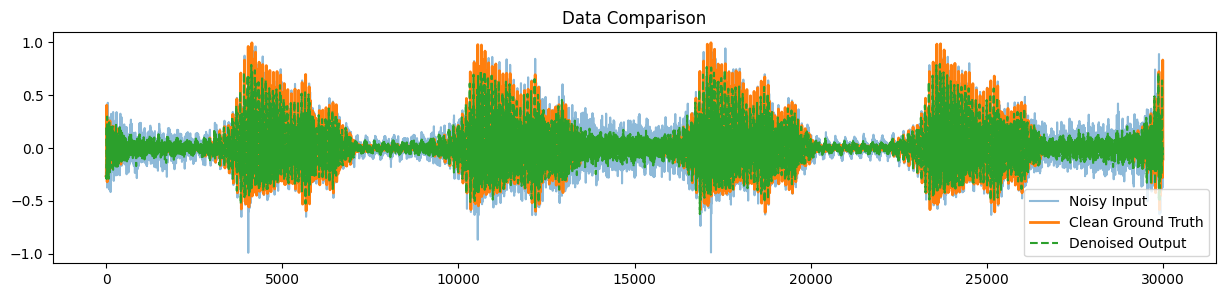

In [10]:
import random

# peak at some samples
def peak_sample_perf(noisy_sample, clean_sample, weights):
    plt.figure(figsize=(15, 3))
    # example for one data snippet
    denoised_audio = np.convolve(noisy_sample, weights, mode='same')

    save_audio(denoised_audio, 16000, output_path="../data/generated.wav")

    plt.title("Data Comparison")
    plt.plot(noisy_sample, label="Noisy Input", alpha=0.5)
    plt.plot(clean_sample, label="Clean Ground Truth", linewidth=2)
    plt.plot(denoised_audio, label="Denoised Output", linestyle='--')
    plt.legend()

    plt.show()

test_x = [i[0] for i in test_set]
test_y = [i[1] for i in test_set]

r = random.randint(1, 50)
peak_sample_perf(test_x[r], test_y[r], weights)

In [27]:
# calc average test set MSE
def calc_loss(eval_x, eval_y, weights, K=38):
    total_mse = 0.0
    for x, y in zip(eval_x, eval_y):
        denoised_audio = np.convolve(x, weights, mode='full')
        valid_denoised = denoised_audio[K-1 : len(x)]
        valid_y = y[K-1 : len(x)]
        
        mse = np.sum((valid_denoised - valid_y) ** 2)
        total_mse += mse

    # Return the average MSE across all files in the dataset
    return total_mse / len(eval_x)

print(calc_loss(test_x, test_y, weights))
print(calc_loss(train_x, train_y, weights))

98.04971
81.62057


saved audio to: ../data/generated.wav


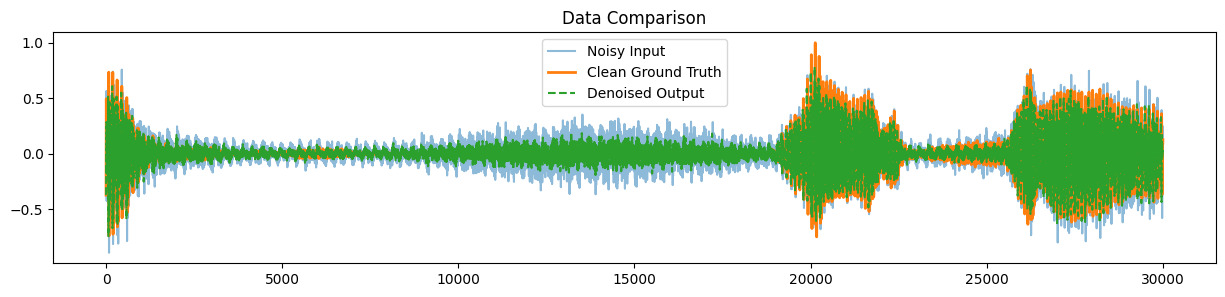

In [15]:
peak_sample_perf(train_x[r], train_y[r], weights)